# Module 2 — Part 1: Data Loading, Sanity Checks & Preprocessing

**Objective:** Load the model-ready data handed off from Module 1, verify its quality, and build the shared preprocessing pipeline used by both the classification model (Part 2) and the regression model (Part 3).

**Input files (from Module 1):**
- `X_train.csv`, `X_test.csv` — 39 engineered features
- `y_train.csv`, `y_test.csv` — target: `late_delivery_risk` (binary)
- `delay_y_train.csv`, `delay_y_test.csv` — target: `delay_duration_days` (0–4)


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Load Data

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')['late_delivery_risk']
y_test = pd.read_csv('y_test.csv')['late_delivery_risk']
delay_y_train = pd.read_csv('delay_y_train.csv')['delay_duration_days']
delay_y_test = pd.read_csv('delay_y_test.csv')['delay_duration_days']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


X_train: (144415, 39), X_test: (36104, 39)


## 3. Data Sanity Checks

In [3]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print()
print("late_delivery_risk balance (train):")
print(y_train.value_counts(normalize=True))
print()
print("delay_duration_days distribution (train):")
print(delay_y_train.value_counts(normalize=True).sort_index())


Missing values in X_train: 0
Missing values in X_test: 0

late_delivery_risk balance (train):
late_delivery_risk
1    0.548288
0    0.451712
Name: proportion, dtype: float64

delay_duration_days distribution (train):
delay_duration_days
0    0.427469
1    0.335325
2    0.158785
3    0.039352
4    0.039068
Name: proportion, dtype: float64


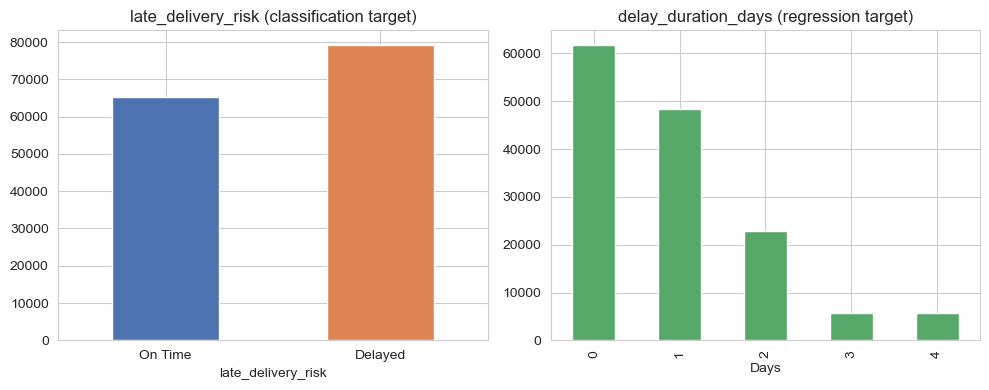

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_xticklabels(['On Time', 'Delayed'], rotation=0)
axes[0].set_title('late_delivery_risk (classification target)')

delay_y_train.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('delay_duration_days (regression target)')
axes[1].set_xlabel('Days')
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

Key decisions:
- Drop `order_date_dateorders` — already decomposed into `order_year`, `order_month`, `order_quarter`, `order_day_of_week`, `order_week`.
- High-cardinality categoricals (e.g. `order_city` with 3,581 values) → frequency encode, fit on train only.
- Low-cardinality categoricals → one-hot encode.


In [6]:
# Drop the raw date column (already decomposed into usable parts)
drop_cols = ['order_date_dateorders']

X_train_p = X_train.drop(columns=drop_cols).copy()
X_test_p = X_test.drop(columns=drop_cols).copy()

cat_cols = X_train_p.select_dtypes(include=['object']).columns.tolist()
cardinality = X_train_p[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)


order_city           3581
order_state          1086
customer_city         563
order_country         164
category_name          50
customer_state         46
order_region           23
order_month_name       12
department_name        11
order_status            9
order_day_of_week       7
market                  5
type                    4
shipping_mode           4
customer_segment        3
customer_country        2
dtype: int64


In [7]:
HIGH_CARD_THRESHOLD = 15
high_card_cols = cardinality[cardinality > HIGH_CARD_THRESHOLD].index.tolist()
low_card_cols = cardinality[cardinality <= HIGH_CARD_THRESHOLD].index.tolist()
print("High-cardinality (frequency encode):", high_card_cols)
print("Low-cardinality (one-hot encode):", low_card_cols)


High-cardinality (frequency encode): ['order_city', 'order_state', 'customer_city', 'order_country', 'category_name', 'customer_state', 'order_region']
Low-cardinality (one-hot encode): ['order_month_name', 'department_name', 'order_status', 'order_day_of_week', 'market', 'type', 'shipping_mode', 'customer_segment', 'customer_country']


In [8]:
for col in high_card_cols:
    freq_map = X_train_p[col].value_counts()
    X_train_p[col + '_freq'] = X_train_p[col].map(freq_map)
    X_test_p[col + '_freq'] = X_test_p[col].map(freq_map).fillna(0)

X_train_p = X_train_p.drop(columns=high_card_cols)
X_test_p = X_test_p.drop(columns=high_card_cols)

X_train_p = pd.get_dummies(X_train_p, columns=low_card_cols, drop_first=True)
X_test_p = pd.get_dummies(X_test_p, columns=low_card_cols, drop_first=True)
X_train_p, X_test_p = X_train_p.align(X_test_p, join='left', axis=1, fill_value=0)

print(f"Final feature matrix: train {X_train_p.shape}, test {X_test_p.shape}")


Final feature matrix: train (144415, 77), test (36104, 77)


## 5. Save Preprocessed Data

Saves the processed feature matrices and preprocessing artifacts so Part 2 and Part 3 can load them directly, without repeating this work.


In [9]:
import pickle

X_train_p.to_csv('X_train_processed.csv', index=False)
X_test_p.to_csv('X_test_processed.csv', index=False)

shared_artifacts = {
    'high_card_cols': high_card_cols,
    'low_card_cols': low_card_cols,
    'final_columns': X_train_p.columns.tolist(),
    'drop_cols': drop_cols,
}
with open('shared_preprocessing.pkl', 'wb') as f:
    pickle.dump(shared_artifacts, f)

print("Saved processed data and shared preprocessing artifacts.")


Saved processed data and shared preprocessing artifacts.


## Summary

- Loaded Module 1's train/test data and both targets (`late_delivery_risk`, `delay_duration_days`)
- Verified no missing values, checked target distributions
- Built a leakage-safe preprocessing pipeline (frequency + one-hot encoding, fit on train only)
- Saved processed features for Part 2 (classification) and Part 3 (regression) to reuse

**Next: Part 2 — Classification model for `late_delivery_risk`.**
